In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
dataframe = pd.read_csv("online_retail.csv")

In [ ]:
# to take subset of it
df = dataframe.head(80000).copy()

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      80000 non-null  object 
 1   StockCode    80000 non-null  object 
 2   Description  79524 non-null  object 
 3   Quantity     80000 non-null  int64  
 4   InvoiceDate  80000 non-null  object 
 5   Price        80000 non-null  float64
 6   Customer ID  56702 non-null  float64
 7   Country      80000 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 4.9+ MB


In [ ]:
df.describe()

,Quantity,Price,Customer ID
count,80000.000000,80000.000000,56702.000000
mean,10.248212,4.732132,15363.640930
std,85.539724,53.848082,1678.418331
min,-3669.000000,0.000000,12346.000000
25%,1.000000,1.250000,14031.000000
50%,3.000000,2.550000,15311.000000
75%,8.000000,4.650000,16802.000000
max,9312.000000,8985.600000,18287.000000


In [ ]:
df.shape

(80000, 8)

In [ ]:
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,476
Quantity,0
InvoiceDate,0
Price,0
Customer ID,23298
Country,0


- **Data preprocessing**

  - Detect & Handle Duplicates
  - Detect & Handle NaNs
  - Detect & Handle Outliers
  - Scaling: MinMaxScaler

In [ ]:
# Detect and Handle Duplicates
df.duplicated().sum()

np.int64(876)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
# Check again
df.duplicated().sum()

np.int64(0)

In [ ]:
# Handling Missing Values in ["Customer ID"]
df.dropna(subset = ["Customer ID"], inplace = True)
df["Customer ID"] = df["Customer ID"].round().astype(int)

In [ ]:
# Handling Missing Values in ["Description"]
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df["Description"] = imputer.fit_transform(df[["Description"]]).ravel()

In [ ]:
# To check "Customer ID" Nan values
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


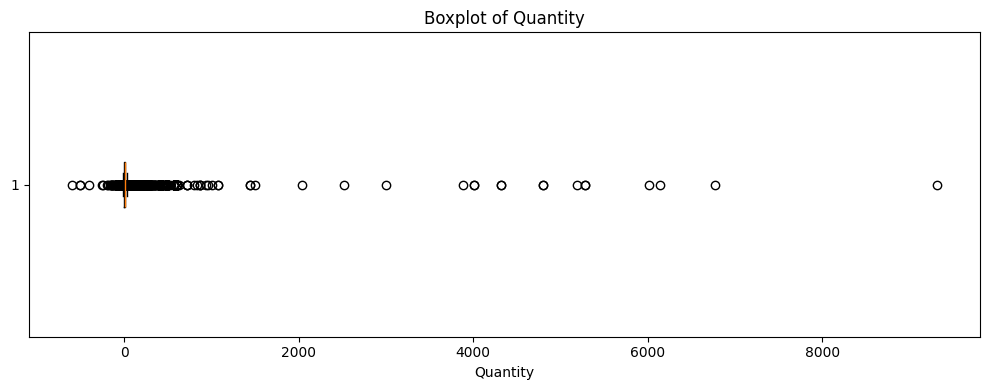

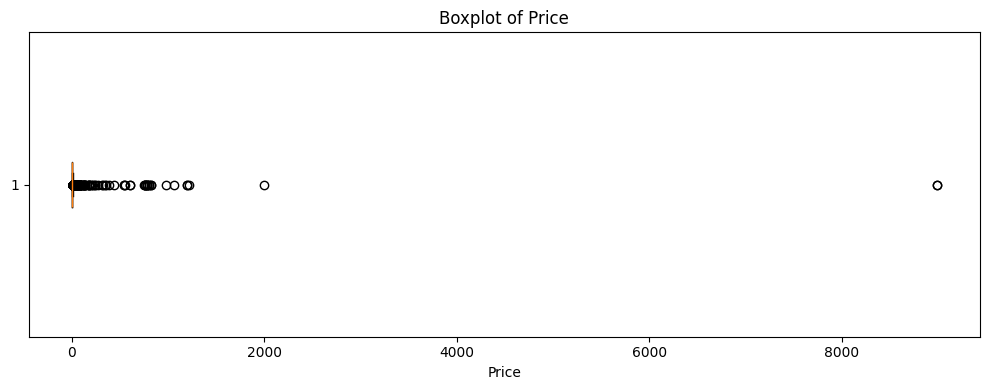

In [ ]:
# Detect Outliers
num_cols = ["Quantity", "Price"]

for col in num_cols:
    plt.figure(figsize=(10, 4))

    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


In [ ]:
df = df[(df['Quantity']>0) & (df['Price']>0)]
df.shape

(54152, 8)

In [ ]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from Quantity
df = remove_outliers_iqr(df, 'Quantity')

# Then remove outliers from Price
df = remove_outliers_iqr(df, 'Price')

print("Data shape after removing outliers:", df.shape)

Data shape after removing outliers: (47630, 8)


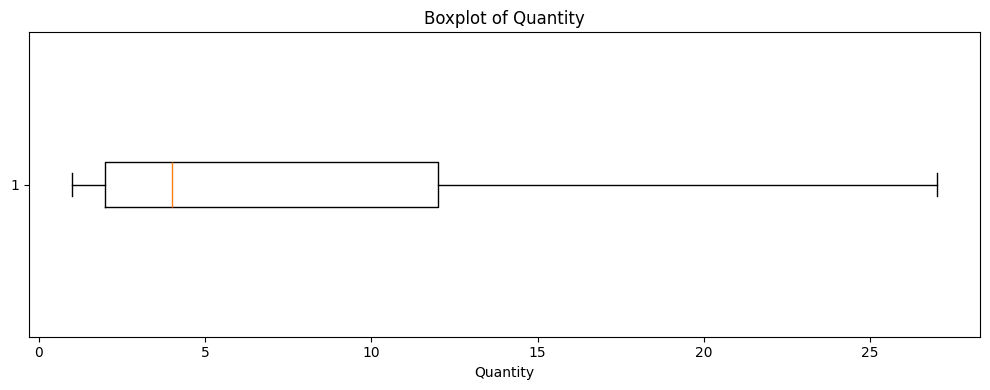

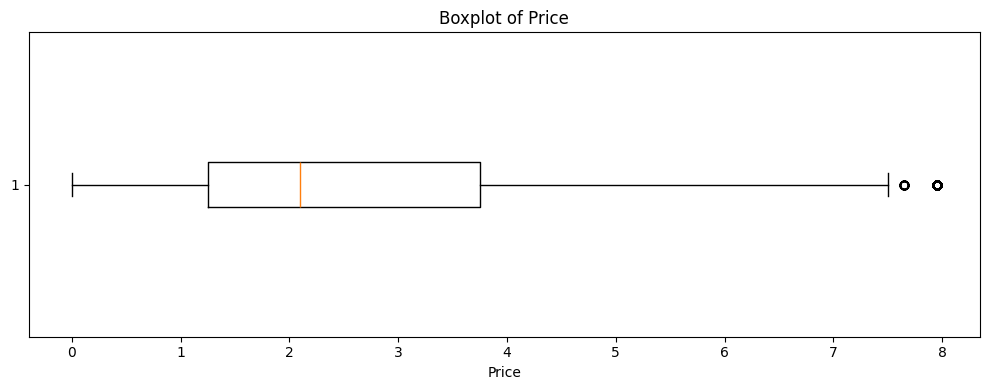

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 4))

    # Boxplot
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

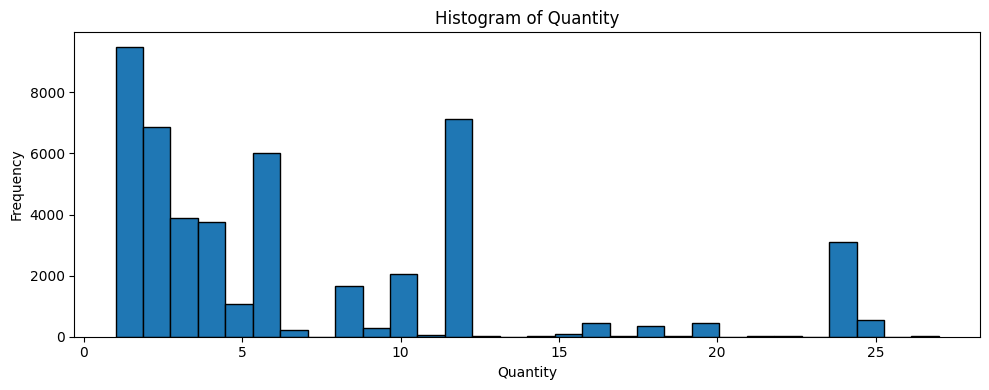

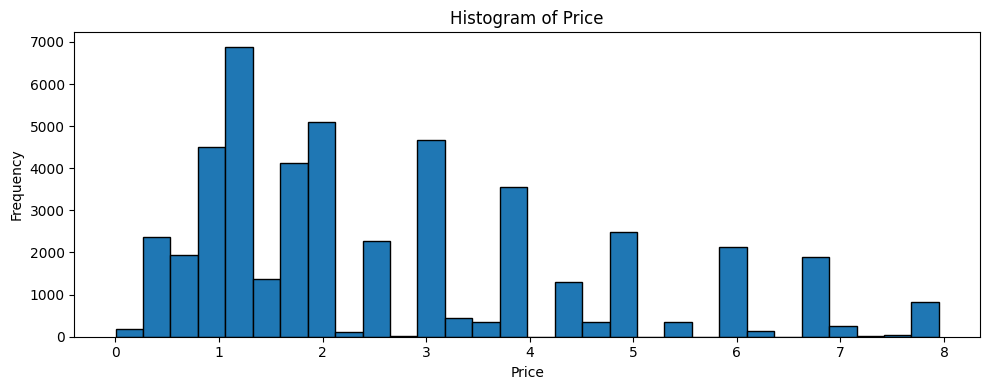

In [ ]:
# Check for Ouliers
for col in num_cols:
    plt.figure(figsize=(10, 4))

    plt.hist(df[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [ ]:
df['Description'] = df['Description'].str.strip().str.capitalize()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df_2 = df.copy()

In [ ]:
df_2.drop("Customer ID",axis =1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,United Kingdom
1,489434,79323P,Pink cherry lights,12,2009-12-01 07:45:00,6.75,United Kingdom
2,489434,79323W,White cherry lights,12,2009-12-01 07:45:00,6.75,United Kingdom
4,489434,21232,Strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,United Kingdom
5,489434,22064,Pink doughnut trinket pot,24,2009-12-01 07:45:00,1.65,United Kingdom
...,...,...,...,...,...,...,...
79994,496677,84987,Set of 36 teatime paper doilies,2,2010-02-03 12:46:00,1.45,United Kingdom
79995,496677,84988,Set of 72 pink heart paper doilies,2,2010-02-03 12:46:00,1.45,United Kingdom
79996,496677,47556B,Tea time tea towels,3,2010-02-03 12:46:00,2.95,United Kingdom
79998,496677,21232,Strawberry ceramic trinket box,2,2010-02-03 12:46:00,1.25,United Kingdom


In [ ]:
# Handle the ["InvoiceDate"] object
df_2["InvoiceDate"] = pd.to_datetime(df_2["InvoiceDate"], errors = "coerce")

# Turn date Object into year-month-day to enter in the model
df_2["year_InvoiceDate"] = df_2["InvoiceDate"].dt.year
df_2["month_InvoiceDate"] = df_2["InvoiceDate"].dt.month
df_2["day_InvoiceDate"] = df_2["InvoiceDate"].dt.day
df_2["weekday_InvoiceDate"] = df_2["InvoiceDate"].dt.weekday

# Drop the real column
df_2.drop(["InvoiceDate"], axis = 1, inplace = True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction import FeatureHasher

labelencoder = LabelEncoder()
df_2["Country"] = labelencoder.fit_transform(df_2["Country"])

hashing = FeatureHasher(n_features = 50, input_type = "string")
col_with_hashencoder = ["Description", "StockCode", "Invoice"]

for col in col_with_hashencoder:
    hashing_x = hashing.fit_transform(df_2[col].astype(str).values.reshape(-1, 1))
    hashing_df = pd.DataFrame(hashing_x.toarray(),columns = [f'hash_feature_{i}' for i in range(hashing.n_features)])
    df_2 = pd.concat([df_2.reset_index(drop = True), hashing_df], axis = 1)
    df_2.drop([col], axis = 1, inplace = True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
x_scaler = scaler.fit_transform(df_2)

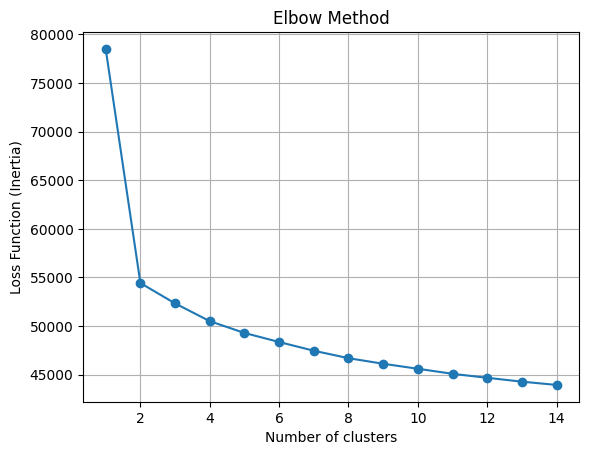

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

i_list = []
k_range = range(1,15)

for i in k_range:
    kmean = KMeans(n_clusters=i, init="k-means++", n_init=10, random_state=42)
    kmean.fit(x_scaler)
    i_list.append(kmean.inertia_)

plt.plot(k_range, i_list, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Loss Function (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

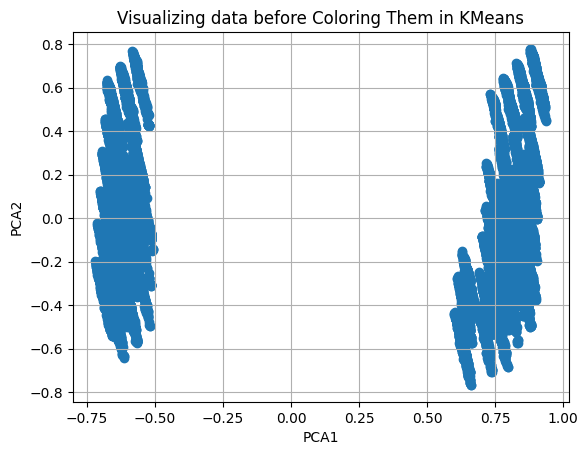

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaler)

plt.scatter(x = x_pca[:, 0], y = x_pca[:, 1])
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Visualizing data before Coloring Them in KMeans")
plt.grid(True)
plt.show()

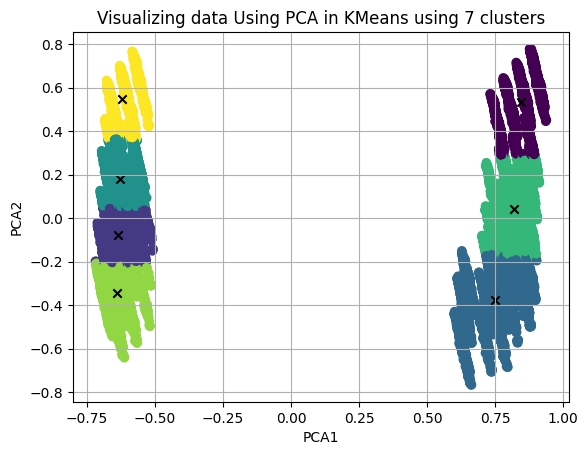

silhouette_score in KMean =  0.5386295021064355
davis bouldin score in KMeans =  0.5714765894855985


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

n_clusters = 7
kmean = KMeans(n_clusters = n_clusters, init = "k-means++")
cluster_labels = kmean.fit_predict(x_pca)

plt.scatter(x = x_pca[:, 0], y = x_pca[:, 1], c = cluster_labels)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title(f"Visualizing data Using PCA in KMeans using {n_clusters} clusters")
plt.grid(True)

centroids = kmean.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c = "black", marker = 'x')
plt.show()

Silhouette_score = silhouette_score(x_pca, cluster_labels)
Davies_bouldin_score = davies_bouldin_score(x_pca, cluster_labels)

print("silhouette_score in KMean = ", Silhouette_score)
print("davis bouldin score in KMeans = ", Davies_bouldin_score)

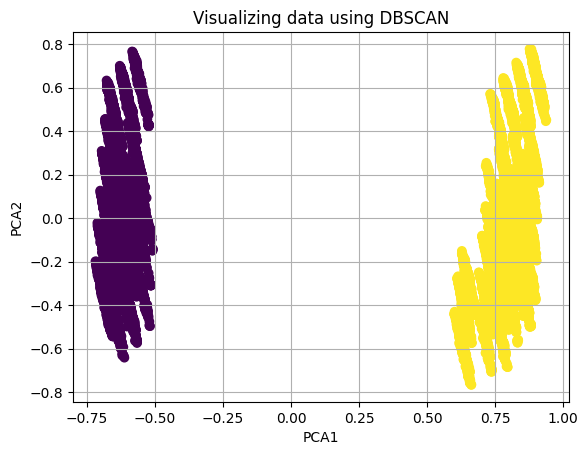

silhouette_score in DBSCAN =  0.739559286222267
davis bouldin score in DBSCAN =  0.4032561906149328


In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 0.3, min_samples = 40, metric = "euclidean")
x_pca2 = pca.fit_transform(x_scaler)

cluster_labels = dbscan.fit_predict(x_pca2)

plt.scatter(x_pca2[:, 0], x_pca2[:, 1], c = cluster_labels)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.title("Visualizing data using DBSCAN")
plt.show()

Silhouette_score = silhouette_score(x_pca, cluster_labels)
Davies_bouldin_score = davies_bouldin_score(x_pca, cluster_labels)
print("silhouette_score in DBSCAN = ", Silhouette_score)
print("davis bouldin score in DBSCAN = ", Davies_bouldin_score)
